In [1]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Random Walk Model
- A Random Walk model is a time series model where each value is the sum of the previous value and a random step. Mathematically, it is expressed as:
    - Xt = C + Xt−1 + ϵt
​- where Xt is the current value, 
- Xt−1 is the previous value, and 
- ϵt is a random error term. It is non-stationary and often used to model unpredictable processes like stock prices. Also called as **White noise**
- **C is a constant**. if the constant C is nonzero, we designate this process as a random walk with drift.
- **Lets predict Google stock price**
- using the random walk model. To do so, we will first determine whether our process is stationary or not. 
- If it is a non-stationary process, we will have to apply transformations, such as differencing, in order to make it stationary. - Then we will be able to use the autocorrelation function plot to conclude that the daily closing price of GOOGL can be approximated by the random walk model.

- **One simulation**
    - If we initailize our first observation as 0, and C to 0, then y1 = ϵ1, y2 = ϵ1 + ϵ2 , y3 = ϵ1 + ϵ2 + ϵ3 ....
    - to get random observations, we need to initiaize ϵi . For reproduciablity, lets have a seed. 



## GOOGL - April 28, 2020 to April 27, 2021

In [2]:
df = pd.read_csv('../data/GOOGL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


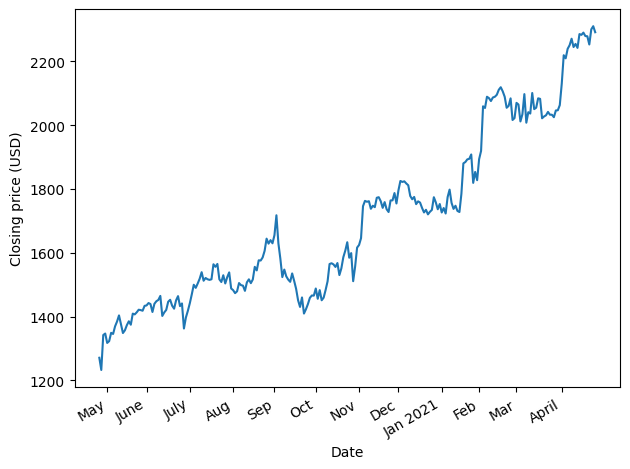

In [4]:
fig, ax = plt.subplots()

ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH03_F01_peixeiro.png', dpi=300)

## 3.1 The random walk process 

- A random walk is a process in which there is an equal chance of going up or down by a random number. This is usually observed in financial and economic data

In [8]:
np.random.seed(42)

steps = np.random.standard_normal(1000)
steps[0]=0 # initialize the first value to 0 so that the random walk starts at 0

random_walk = np.cumsum(steps) # Calculate the cumulative sum of errors for each timestep in the simulated process

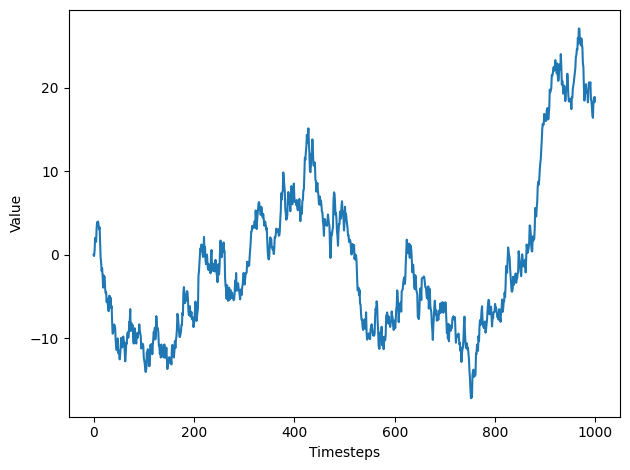

In [9]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('figures/CH03_F03_peixeiro.png', dpi=300)

# identifying a Random walk
- We know this is a random walk because we simulated it. However, when dealing with real-life data, we need to find a way to identify whether our time series is a random walk or not. Let’s see how we can achieve this.

- To determine if our time series can be approximated as a random walk or not, we must first define a random walk. In the context of time series, a random walk is defined as a series whose first difference is stationary and uncorrelated.

- A **random walk** is a series whose first difference is stationary and uncorrelated. This means that the process moves completely at random.

- 1. Gather Data
    - a. is it stationary
        - i.  Yes - Plot ACF (Auto correlation function)
            - is there Auto correlation
                - **yes - its not random walk**
                - **No - it is random walk**    
        - ii. NO - Appaly transformation -> Then go to step a, to check if it is stationary.


- ### Stationarity
- A stationary time series is one whose statistical properties do not change over time. In other words, it has a constant mean, variance, and autocorrelation, and these proper- ties are independent of time.
    - Many forecasting models assume stationarity
- if the data is non-stationary, its properties are going to change over time, which would mean that our model parame- ters must also change through time.
- This means that we cannot possibly derive a function of future values as a function of past values, since the coefficients change at each point in time, making forecasting unreliable.

- we will need to find ways to transform our time series to make them stationary
- A transformation is simply a mathematical manipula- tion of the data that stabilizes its mean and variance, thus making it stationary.
- The simplest transformation one can apply is **differencing**. This transformation helps stabilize the mean, which in turn removes or reduces the trend and seasonality effects

- **Differencing** is a transformation that calculates the change from one timestep to another. This transformation is useful for stabilizing the mean
    - Y't = Yt - Yt-1.  (we simply subtract the value of the previous timestep yt–1 from the value in the present yt)

![First Order differencing ](../CH03/figures/first-order-differencing.jpeg)

- It is possible to difference a time series many times. Taking the difference once is applying a **first-order differencing**. 
- Taking it a second time would be a **second-order differencing**. It is often not necessary to difference more than twice to obtain a stationary series.

- We must also make sure we have a **constant variance** in order for our process to be stationary.
    - Applying a log function to the series can stabilize its variance.

- We must untransform it to return the results of the model to the original units of measurement. The formal term for undoing a transformation is **inverse transform**. 
    - Therefore, if you apply a **log transformation** to your data, make sure you **raise your forecast values to the power of 10** in order to bring the values back to their original magnitude. That way, your predictions will make sense in their original context.    

### 3.2.2 Testing for stationarity 

- we need to test for stationarity to determine if we need to apply another transformation to make the time series stationary, or if we need to transform it at all. 
    - A common test is the **augmented Dickey-Fuller (ADF) test**.

#### Augmented Dickey-Fuller (ADF) test
- The **augmented Dickey-Fuller (ADF) test** helps us determine if a time series is station- ary by testing for the presence of a unit root. If a unit root is present, the time series is not stationary.    
    - yt = C + 𝜶1yt-1 + 𝜀t
        - 𝜀t represents some error, we can't predict.
        - C is constant
        - 𝜶1 is th eroot of the time series. The time series is stationary only if the root lies within a unit circle. therefor its value must be bewteen -1 to 1 for making a time series stationary or else the series is not stationary.

    - Example:
        - **yt = 0.5yt-1 + 𝜀t** -> this is a stationary time series.
        - **yt = yt-1 + 𝜀t** -> here the  𝜶 , root is 1. So it is not in between -1 to 1, it is non-stationary.  

    - Lets simulate these 2 Equaltions.     


In [13]:
def simulate_process(is_stationary: bool) -> np.array:
    np.random.seed(42)
    process = np.empty(400)
    
    if is_stationary:
        alpha = 0.5
        process[0] = 10
    else:
        alpha = 1
        process[0] = 10
        
    for i in range(400):
        if i+1 < 400:
            process[i+1] = alpha*process[i] + np.random.standard_normal()
        else:
            break
        
    return process

In [14]:
stationary = simulate_process(True)
non_stationary = simulate_process(False)

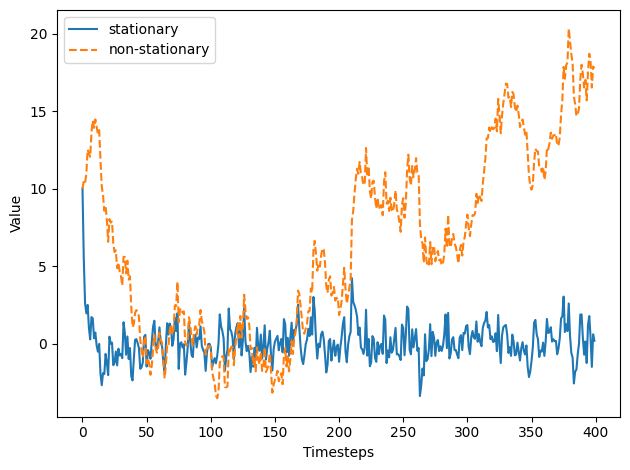

In [15]:
fig, ax = plt.subplots()

ax.plot(stationary, linestyle='-', label='stationary')
ax.plot(non_stationary, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.legend(loc=2)

plt.tight_layout()
plt.savefig('figures/CH03_F06_peixeiro.png', dpi=300)

In [16]:
def mean_over_time(process: np.array) -> np.array:
    mean_func = []
    
    for i in range(len(process)):
        mean_func.append(np.mean(process[:i]))
    
    return mean_func

In [17]:
stationary_mean = mean_over_time(stationary)
non_stationary_mean = mean_over_time(non_stationary)

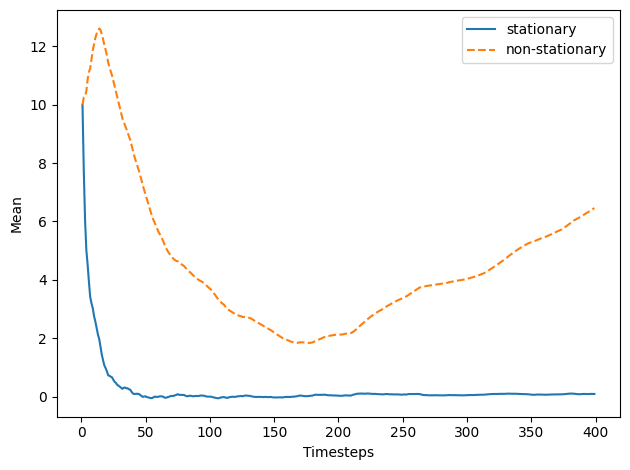

In [18]:
fig, ax = plt.subplots()

ax.plot(stationary_mean, label='stationary')
ax.plot(non_stationary_mean, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Mean')
ax.legend(loc=1)

plt.tight_layout()
plt.savefig('figures/CH03_F07_peixeiro.png', dpi=300)

In [19]:
def var_over_time(process: np.array) -> np.array:
    var_func = []
    
    for i in range(len(process)):
        var_func.append(np.var(process[:i]))
    
    return var_func

In [20]:
stationary_var = var_over_time(stationary)
non_stationary_var = var_over_time(non_stationary)

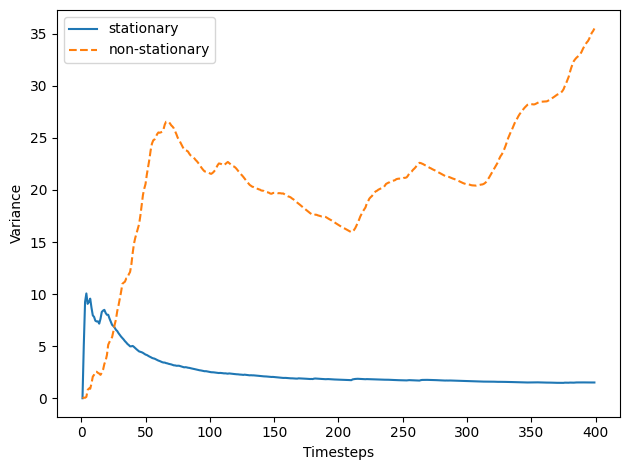

In [21]:
fig, ax = plt.subplots()

ax.plot(stationary_var, label='stationary')
ax.plot(non_stationary_var, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Variance')
ax.legend(loc=2)

plt.tight_layout()
plt.savefig('figures/CH03_F08_peixeiro.png', dpi=300)

- The presence of a unit root in `non_stationary_var` makes the mean of the series dependent on time, so the series is not stationary
- a stationary series will have a **constant variance over time**, meaning that it is **time independent**. On the other hand, the non-stationary process will have a variance that changes over time.

### Lag
- **Lag** refers to the time difference between the current observation and a past observation in the time series. For example:
    - **Lag 1**: Compares the current value with the value one time step earlier.
    - **Lag 2**: Compares the current value with the value two time steps earlier, and so on.

- **Example**
    - Let’s consider a simple time series:
    - [ X = [10, 20, 30, 40, 50] ]

    - **Lag 1**: Compare each value with the one before it:
        - Pairs: ((10, 20), (20, 30), (30, 40), (40, 50))
        - **Lag1**: [-10, -10,-10,-10]
        - Compute the correlation between these pairs.
    - **Lag 2**: Compare each value with the one two steps before:
        - Pairs: ((10, 30), (20, 40), (30, 50))
        - **Lag1**: [-20, -20,-20]    

### Autocorrelation
- Autocorrelation measures the similarity between a time series and a **lagged version of itself** over successive time intervals. It quantifies how the current value of a time series is related to its past values.
    - **Positive Autocorrelation**: When high values tend to follow high values, and low values follow low values.
    - **Negative Autocorrelation**: When high values tend to follow low values, and vice versa.
    - **No Autocorrelation**: When there is no predictable relationship between current and past values.

- at **Lag 0**:   Always has an autocorrelation of 1 because the series is perfectly correlated with itself.
- at **Lag 1**: It first creates the Lag1 series, then checks how Lag1 series is correlated with original series.
    - If Lag 1 has a high positive bar, it means the current value is strongly related to the previous value.
- at **Lag 2**:  It first creates the Lag1 series, then checks how Lag1 series is correlated with original series. 
    - If Lag 2 has a smaller bar, the relationship weakens as the lag increases.

#### Intrepreating Auto-correlation plot
- **X-axis (Lag)**: Represents the lag values (e.g., Lag 1, Lag 2, etc.). A lag of 1 means comparing the time series with its values shifted by one time step, and so on.  
- **Y-axis (Autocorrelation)**: Represents the correlation coefficient (( r_k )) for each lag. The value ranges from -1 to 1:

( r_k = 1 ): Perfect positive correlation.
( r_k = -1 ): Perfect negative correlation.
( r_k = 0 ): No correlation.

- **Bars:** Each bar represents the autocorrelation value for a specific lag. The height of the bar indicates the strength of the correlation.

- **Confidence Interval (Shaded Region)**: The shaded area around the x-axis represents the confidence interval. Bars outside this region indicate statistically significant autocorrelation.

- **Interpretation:**
    - **Bars within the Confidence Interval**: No significant autocorrelation at that lag.
    - **Bars outside the Confidence Interval**: Significant autocorrelation at that lag.
    - **Gradual Decline in Bar Heights**: Indicates a trend in the data (e.g., non-stationary series).
    - **Repeating Patterns**: Suggest seasonality in the data.

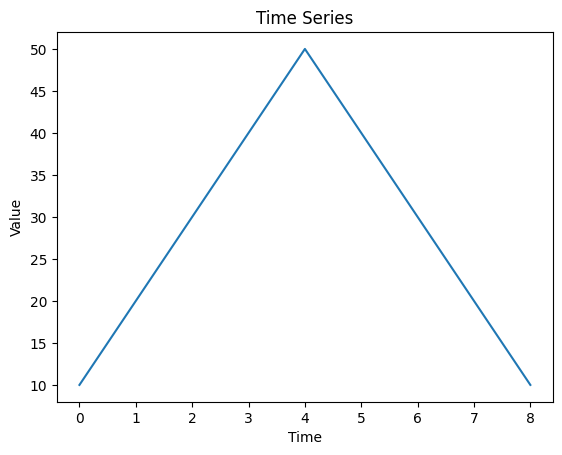

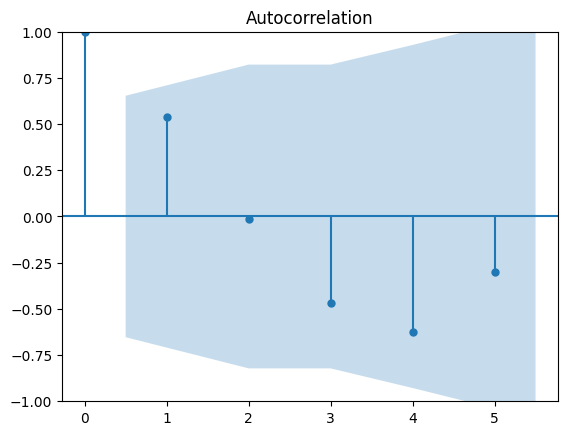

In [ ]:
# Example time series
time_series = [10, 20, 30, 40, 50, 40, 30, 20, 10]

# Plot the time series
plt.plot(time_series)
plt.title("Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# Autocorrelation plot
plot_acf(time_series, lags=5) # plot till lag 5 to see the autocorrelation of the time series with itself at different lags
plt.show()

### 3.2.4 Putting it all together 

In [22]:
ADF_result = adfuller(random_walk)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -0.9659524876918768
p-value: 0.7654789696692574


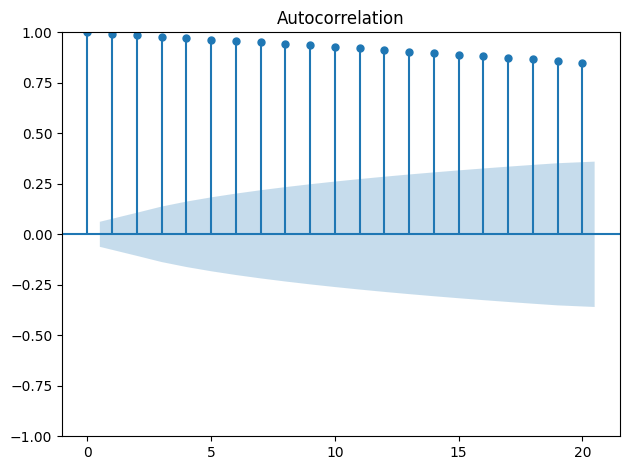

In [23]:
plot_acf(random_walk, lags=20);

plt.tight_layout()
plt.savefig('figures/CH03_F09_peixeiro.png', dpi=300)

- you’ll notice how the autocorrelation coefficients slowly decrease as the lag increases, which is a clear indicator that our random walk is not a stationary process
- If a point is within the shaded area, then it is not significantly different from 0. Otherwise, the autocor- relation coefficient is significant.
- Since our sequence mostly displays changes in the trend without seasonal patterns, we will apply a **first-order differencing**

In [ ]:
diff_random_walk = np.diff(random_walk, n=1) # n =1 means we are taking the first difference of the random walk, which is the difference between each value and the previous value in the series

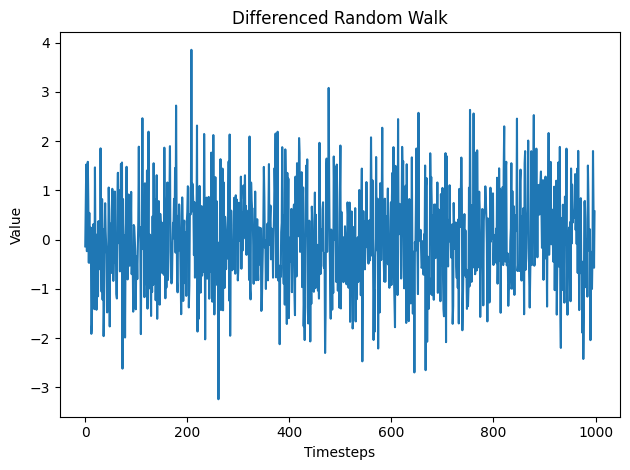

In [26]:
plt.plot(diff_random_walk)
plt.title('Differenced Random Walk')
plt.xlabel('Timesteps')
plt.ylabel('Value')
plt.tight_layout()

plt.savefig('figures/CH03_F10_peixeiro.png', dpi=300)

- **It seems that we successfully removed the trend and that the variance is stable.**
- Let’s test for stationarity again, using the ADF test:

In [27]:
ADF_result = adfuller(diff_random_walk)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -31.789310857560615
p-value: 0.0


- This prints out an ADF statistic of –31.79 with a p-value of 0. 
- This time the ADF statistic is a large negative number, and the p-value is less than 0.05. 
- Therefore, we reject the null hypothesis, and we can say that this process has no unit root and is thus stationary.

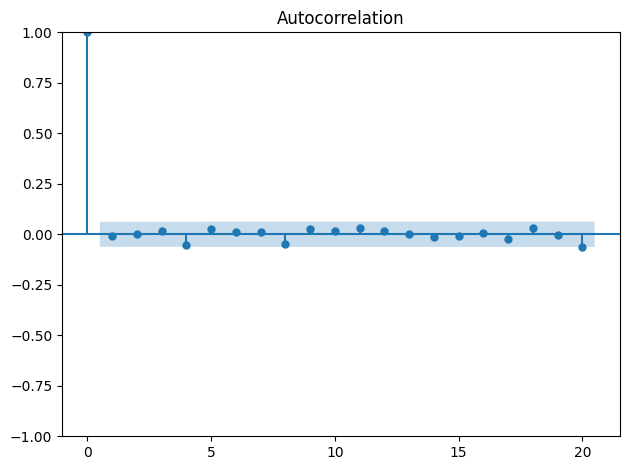

In [28]:
plot_acf(diff_random_walk, lags=20);

plt.tight_layout()

plt.savefig('figures/CH03_F11_peixeiro.png', dpi=300)

- Notice that there are no significant autocorrelation coefficients after lag 0.
- This means that the stationary process is completely random and can therefore be described as white noise. 
- Each value is simply a random step away from the previous one, with no relation between them.

### 3.2.5 Is GOOGL a random walk? 

In [21]:
GOOGL_ADF_result = adfuller(df['Close'])

print(f'ADF Statistic: {GOOGL_ADF_result[0]}')
print(f'p-value: {GOOGL_ADF_result[1]}')

ADF Statistic: 0.16025048664771271
p-value: 0.9699419435913057


- This returns an ADF statistic of 0.16 and a p-value greater than 0.05, 
- so we know that our data is not stationary. Hence, we will difference our data to see if that makes it stationary:

In [33]:
diff_close = np.diff(df['Close'], n=1) # n=1 means we are taking the first difference of the closing price, which is the difference between each value and the previous value in the series

In [34]:
GOOGL_diff_ADF_result = adfuller(diff_close)

print(f'ADF Statistic: {GOOGL_diff_ADF_result[0]}')
print(f'p-value: {GOOGL_diff_ADF_result[1]}')

ADF Statistic: -5.303439704295224
p-value: 5.386530961454829e-06


- This gives an ADF statistic of –5.3 and a p-value smaller than 0.05, meaning that we have a stationary process.

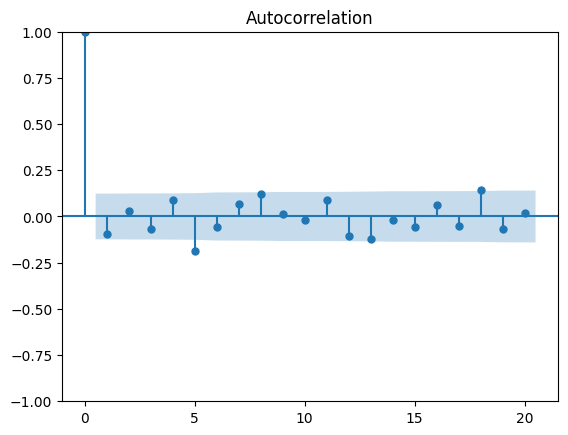

In [35]:
plot_acf(diff_close, lags=20);

plt.savefig('figures/CH03_F13_peixeiro.png', dpi=300)

- We do not see any significant coefficients, except at lags 5 and 18. 
- This situation can arise sometimes, and it is due to chance only. 
- In such a situation, we can safely assume that the coefficients at lags 5 and 18 are not significant, because we do not have consecutive significant coefficients.
- Therefore, we can conclude that the closing price of GOOGL can be approximated by a random walk process.

## 3.3 Forecasting a random walk
### 3.3.1 Forecasting on a long horizon

In [43]:
df = pd.DataFrame({'value': random_walk})

train = df[:800]
test = df[800:]

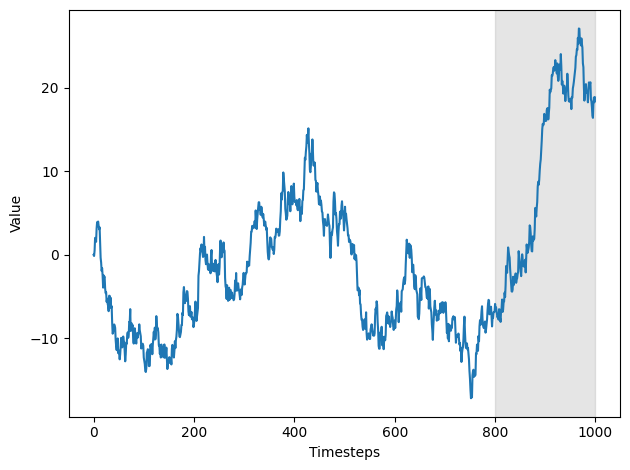

In [44]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(800, 1000, color='#808080', alpha=0.2)

plt.tight_layout()
plt.savefig('figures/CH03_F14_peixeiro.png', dpi=300)

In [46]:
# One baseline is use the mean of the training set as the prediction for all values in the test set

mean = np.mean(train.value) # calculate the mean of the training set to use as a naive forecast for the test set

test.loc[:, 'pred_mean'] = mean # assign the mean value as the prediction for all values in the test set

test.head()

,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


In [47]:
# Another baseline is to use the last value of the training set as the prediction for all values in the test set
last_value = train.iloc[-1].value

test.loc[:, 'pred_last'] = last_value

test.head()

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


### Drift Method
- The drift method is a modification of predicting the last known value. 
- In this case, we allow the values to increase or decrease over time. 
- The rate at which values will change in the future is equal to that seen in the train set. 
- Therefore, it is equivalent to calculating the slope between the first and last value of the train set and simply extrapolating this straight line into the future.


In [49]:
# Calculate the change in the x-axis, which is the difference between the last index (799) and first index (0). 
# It is equivalent to the number of timesteps minus 1.
deltaX = 800 - 1 

#Calculate the difference between the last and initial values of the simulated random walk in the train set. 
# Recall that the last value of the train set is in the last_value variable from the previous baseline we implemented.
deltaY = last_value - 0

drift = deltaY / deltaX

# Create a list containing the range of timesteps starting at 800 and ending at 1000 with a step of 1.
x_vals = np.arange(801, 1001, 1)


#Multiply each timestep by the drift to get the forecast value at each timestep.
pred_drift = drift * x_vals

test.loc[:, 'pred_drift'] = pred_drift

test.head()

,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.832006
801,-6.392708,-3.677206,-6.814947,-6.840536
802,-6.296588,-3.677206,-6.814947,-6.849065
803,-6.758863,-3.677206,-6.814947,-6.857594
804,-7.193359,-3.677206,-6.814947,-6.866124


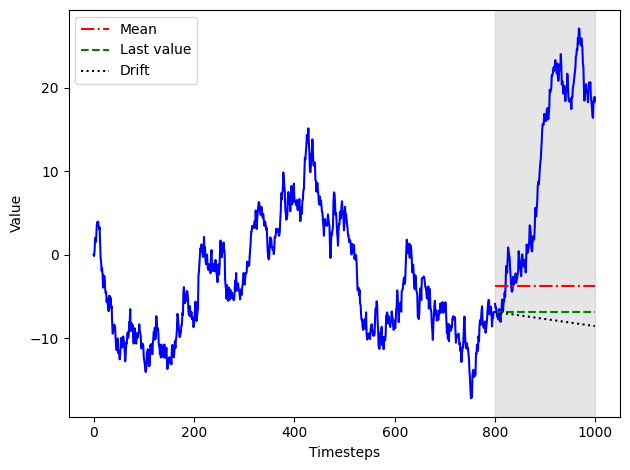

In [41]:
fig, ax = plt.subplots()

ax.plot(train.value, 'b-')
ax.plot(test['value'], 'b-')
ax.plot(test['pred_mean'], 'r-.', label='Mean')
ax.plot(test['pred_last'], 'g--', label='Last value')
ax.plot(test['pred_drift'], 'k:', label='Drift')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('figures/CH03_F15_peixeiro.png', dpi=300)

In [42]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last'])
mse_drift = mean_squared_error(test['value'], test['pred_drift'])

print(mse_mean, mse_last, mse_drift)

326.50277395297434 425.17260330556167 466.2172769077409


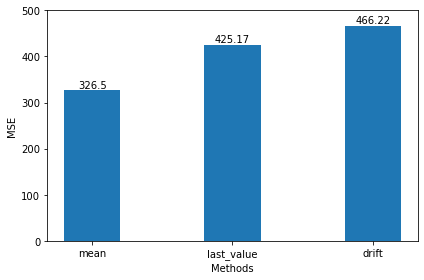

In [33]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'drift']
y = [mse_mean, mse_last, mse_drift]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 500)

for index, value in enumerate(y):
    plt.text(x=index, y=value+5, s=str(round(value, 2)), ha='center')

plt.tight_layout()

plt.savefig('figures/CH03_F16_peixeiro.png', dpi=300)

### 3.3.2 Forecasting the next timestep 

In [37]:
df_shift = df.shift(periods=1)

df_shift.head()

,value
0,NaN
1,0.000000
2,-0.138264
3,0.509424
4,2.032454


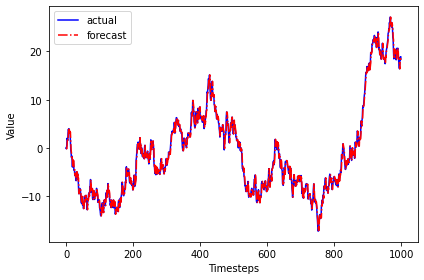

In [38]:
fig, ax = plt.subplots()

ax.plot(df, 'b-', label='actual')
ax.plot(df_shift, 'r-.', label='forecast')

ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

plt.savefig('figures/CH03_F18_peixeiro.png', dpi=300)

In [39]:
mse_one_step = mean_squared_error(test['value'], df_shift[800:])

mse_one_step

0.9256876651440581

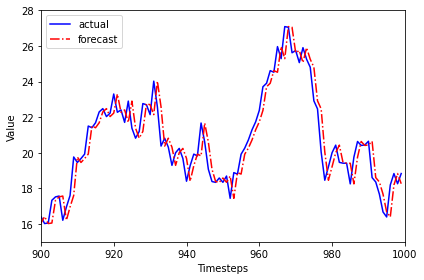

In [40]:
fig, ax = plt.subplots()

ax.plot(df, 'b-', label='actual')
ax.plot(df_shift, 'r-.', label='forecast')

ax.legend(loc=2)

ax.set_xlim(900, 1000)
ax.set_ylim(15, 28)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

plt.savefig('figures/CH03_F19_peixeiro.png', dpi=300)